<a href="https://colab.research.google.com/github/peremartra/Rearchitecting-LLMs/blob/main/CH06/CH06_NB03_Hands_on_qwen3_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="width:100%; border:none; background:none;">
  <tr style="border:none;">
    <td style="border:none; vertical-align:middle; text-align:left; width: 120px;">
      <a href="https://hubs.la/Q040tvsK0"><img src="https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/Images/cover.png" width="100px" style="border-radius: 4px;"></a>
    </td>
    <td style="border:none; vertical-align:middle; text-align:left;">
      <p style="margin: 0; font-size: 14px;">
        Supplementary code for the <a href="https://hubs.la/Q040tvsK0">Rearchitecting LLMs</a> book by <a href="https://github.com/peremartra">Pere Martra</a>.<br>
        <br>
        <br>
        Code repository: <a href="https://github.com/peremartra/Rearchitecting-LLMs">https://github.com/peremartra/Rearchitecting-LLMs</a>
      </p>
    </td>
  </tr>
</table>

# **Rearchitecting LLMs**
## **Chapter 6: Knowledge Distillation with hard & soft labels**
### Hands-On development challenge


[![LinkedIn](https://img.shields.io/badge/LinkedIn-0077B5?style=flat&logo=linkedin&logoColor=white)](https://www.linkedin.com/in/pere-martra/) [![GitHub](https://img.shields.io/badge/GitHub-100000?style=flat&logo=github&logoColor=white)](https://github.com/peremartra) [![X](https://img.shields.io/badge/X-000000?style=flat&logo=x&logoColor=white)](https://x.com/PereMartra) [![Hugging Face](https://img.shields.io/badge/🤗%20Hugging%20Face-blue)](https://huggingface.co/oopere)

---

**Hardware Environment:** NVIDIA A100 GPU
- **Model:** Qwen/Qwen3.5-0.8B-Base (Teacher: 18 transformer blocks) → Pruned Student (14 transformer blocks)
- **Dataset:** Cosmopedia (40,000 samples, 5 epochs)

---
This notebook serves as the basis for the creation of the [Qwen/Qwen3.5-0.8B-Base](https://huggingface.co/oopere/Qwen3.5-0.65B-Base-Rearchitected) model available on Hugging Face.

In the Hands-On Lab section of chapter 6 of the book, the following challenge has been launched:

>**What to do**: Using the CH06_NB03_Hands_on.ipynb notebook, create a 14-block student model that surpasses the baseline in at least 1 out of 5 benchmarks (arc_easy, winogrande, hellaswag, lambada_openai, piqa), and in overall recovery. You can modify any aspect of the pipeline: block selection strategy, loss function weights (alpha, beta, gamma), mapping strategy, dataset composition, or training hyperparameters. The notebook automatically generates a model card for you—once you're satisfied with your results, make it public on the Hugging Face Hub.
>
>**Questions to answer**: Which benchmark did you improve the most, and why do you think your configuration worked better for that specific capability? Did improving one benchmark cause degradation in another?


In the Hands-On Lab section of chapter 6 of the book, the following challenge has been launched:

**What we'll accomplish:**
- Train a depth-pruned student model
- No hidden state alignment (simpler, faster training)
- Save the trained model to Hugging Face

___



## Section 0: Environment & Dependencies

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print("✓ Drive mounted")

Mounted at /content/drive
✓ Drive mounted


In [2]:
RECOVERY_SAMPLES = 40000
EPOCHS=1
LEARNING_RATE=4e-5 #2e-5
BATCH_SIZE = 4
BATCH_EVAL="auto"
RUN_FULL_BENCHMARKS = True
BENCHMARK_LIMIT = None
BENCHMARK_TASKS = ["arc_easy", "winogrande", "hellaswag", "lambada_openai", "piqa"]
HF_MODEL_NAME = "Qwen3.5-0.65B-Base-Rearchitected"

In [3]:
!pip install -q --upgrade transformers
!pip install -q accelerate datasets
!pip install -q optipfair matplotlib seaborn tqdm
!pip install -q lm_eval langdetect codecarbon huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 153.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.1/65.1 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 68.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 153.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.5/380.5 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 157.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
import torch, gc
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset, Dataset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm.auto import tqdm
from copy import deepcopy
import warnings, time, json, os
from datetime import datetime
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.10.0+cu128
CUDA available: True
Using device: cuda


In [5]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
set_seed(42)
print("✓ Random seed set to 42")

✓ Random seed set to 42


In [6]:
!wget -q https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/utils.py
from utils import evaluate_metrics, clear_gpu_cache, model_evaluation
print("✓ utils.py loaded")

✓ utils.py loaded


## Section 1: Load Teacher Model

In [7]:
MODEL_NAME = "Qwen/Qwen3.5-0.8B-Base" #"google/gemma-3-270m"
print(f"Loading Teacher model: {MODEL_NAME}")
teacher_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None
)
teacher_model.eval()
for param in teacher_model.parameters():
    param.requires_grad = False

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

n_teacher_layers = len(teacher_model.model.layers)
hidden_dim = teacher_model.config.hidden_size
print(f"Teacher: {n_teacher_layers} layers, {teacher_model.num_parameters():,} params")

Loading Teacher model: Qwen/Qwen3.5-0.8B-Base


config.json: 0.00B [00:00, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model.safetensors-00001-of-00001.safeten(…):   0%|          | 0.00/1.75G [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

Teacher: 24 layers, 752,393,024 params


## Section 2: Prepare Training Dataset

In [8]:
MAX_LENGTH = 512
print("Loading Cosmopedia dataset...")
dataset_name = "HuggingFaceTB/cosmopedia"
subsets = ["stories", "wikihow", "openstax", "web_samples_v1"]
samples_per_subset = int(RECOVERY_SAMPLES / 4)

all_samples = []
for subset in subsets:
    print(f"  Loading {subset}...")
    subset_data = load_dataset(dataset_name, subset, split="train", streaming=True)
    subset_samples = list(subset_data.take(samples_per_subset))
    all_samples.extend(subset_samples)
    print(f"    ✓ {len(subset_samples):,} samples")

distillation_dataset = Dataset.from_dict({'text': [s['text'] for s in all_samples]})
print(f"✓ Total samples: {len(distillation_dataset):,}")

Loading Cosmopedia dataset...
  Loading stories...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/43 [00:00<?, ?it/s]

    ✓ 10,000 samples
  Loading wikihow...


...

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

    ✓ 10,000 samples
  Loading web_samples_v1...


Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/139 [00:00<?, ?it/s]

    ✓ 10,000 samples
✓ Total samples: 40,000


In [9]:
print("Tokenizing...")
texts = [item['text'] for item in distillation_dataset]
tokenized_data = []
for i in tqdm(range(0, len(texts), 1000), desc="Tokenizing"):
    batch = tokenizer(texts[i:i+1000], truncation=True, padding="max_length", max_length=MAX_LENGTH, return_tensors="pt")
    tokenized_data.append(batch)

input_ids = torch.cat([b['input_ids'] for b in tokenized_data], dim=0)
attention_mask = torch.cat([b['attention_mask'] for b in tokenized_data], dim=0)
full_dataset = TensorDataset(input_ids, attention_mask)

generator = torch.Generator().manual_seed(42)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
eval_dataloader_raw = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

class DictDataLoader:
    def __init__(self, dl): self.dataloader = dl
    def __iter__(self):
        for input_ids, attention_mask in self.dataloader:
            yield {'input_ids': input_ids, 'attention_mask': attention_mask}
    def __len__(self): return len(self.dataloader)

eval_dataloader = DictDataLoader(eval_dataloader_raw)
print(f"✓ Train: {len(train_dataset):,}, Val: {len(val_dataset):,}")

Tokenizing...


Tokenizing:   0%|          | 0/40 [00:00<?, ?it/s]

✓ Train: 32,000, Val: 8,000


## Section 3: Create Pruned Student Model

In [10]:
print(teacher_model)

Qwen3_5ForCausalLM(
  (model): Qwen3_5TextModel(
    (embed_tokens): Embedding(248320, 1024)
    (layers): ModuleList(
      (0-2): 3 x Qwen3_5DecoderLayer(
        (linear_attn): Qwen3_5GatedDeltaNet(
          (act): SiLUActivation()
          (conv1d): Conv1d(6144, 6144, kernel_size=(4,), stride=(1,), padding=(3,), groups=6144, bias=False)
          (norm): Qwen3_5RMSNormGated()
          (out_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (in_proj_qkv): Linear(in_features=1024, out_features=6144, bias=False)
          (in_proj_z): Linear(in_features=1024, out_features=2048, bias=False)
          (in_proj_b): Linear(in_features=1024, out_features=16, bias=False)
          (in_proj_a): Linear(in_features=1024, out_features=16, bias=False)
        )
        (mlp): Qwen3_5MLP(
          (gate_proj): Linear(in_features=1024, out_features=3584, bias=False)
          (up_proj): Linear(in_features=1024, out_features=3584, bias=False)
          (down_proj): Linear(

In [11]:
import optipfair as opf
student_model = deepcopy(teacher_model)
importance_scores = opf.analyze_layer_importance(student_model, train_dataloader, show_progress=True)


Processing batches: 100%|██████████| 8000/8000 [37:28<00:00,  3.56it/s]


In [12]:
LAYERS_TO_REMOVE = sorted(importance_scores.keys(), key=lambda x: importance_scores[x])[:4]
print(f"Layers to remove: {LAYERS_TO_REMOVE}")

Layers to remove: [21, 20, 9, 22]


In [13]:
student_model = opf.prune_model_depth(model=student_model, layer_indices=LAYERS_TO_REMOVE, show_progress=True)

for param in student_model.parameters():
    param.requires_grad = True
n_student_layers = len(student_model.model.layers)
print(f"✓ Student: {n_student_layers} layers, {student_model.num_parameters():,} params")

Removing layers: 100%|██████████| 24/24 [00:00<00:00, 306900.29it/s]

✓ Student: 20 layers, 666,171,584 params


In [14]:
print("Evaluating Teacher...")
teacher_metrics = evaluate_metrics(teacher_model, eval_dataloader, device=device)
teacher_ppl = teacher_metrics['perplexity']
teacher_loss = teacher_metrics['loss']

Evaluating Teacher...


Evaluating: 100%|██████████| 2000/2000 [09:06<00:00,  3.66it/s]


In [15]:
print("Evaluating Pruned Student...")
student_model.config.use_cache = False
student_pruned_copy = deepcopy(student_model)
student_metrics = evaluate_metrics(student_pruned_copy, eval_dataloader, device=device)
student_ppl = student_metrics['perplexity']
student_loss = student_metrics['loss']
del student_pruned_copy
clear_gpu_cache()

print(f"Teacher PPL: {teacher_ppl:.2f}, Student PPL: {student_ppl:.2f}")

Evaluating Pruned Student...


Evaluating: 100%|██████████| 2000/2000 [07:06<00:00,  4.69it/s]


Teacher PPL: 7.34, Student PPL: 24.29


In [16]:
print(student_model)

Qwen3_5ForCausalLM(
  (model): Qwen3_5TextModel(
    (embed_tokens): Embedding(248320, 1024)
    (layers): ModuleList(
      (0-2): 3 x Qwen3_5DecoderLayer(
        (linear_attn): Qwen3_5GatedDeltaNet(
          (act): SiLUActivation()
          (conv1d): Conv1d(6144, 6144, kernel_size=(4,), stride=(1,), padding=(3,), groups=6144, bias=False)
          (norm): Qwen3_5RMSNormGated()
          (out_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (in_proj_qkv): Linear(in_features=1024, out_features=6144, bias=False)
          (in_proj_z): Linear(in_features=1024, out_features=2048, bias=False)
          (in_proj_b): Linear(in_features=1024, out_features=16, bias=False)
          (in_proj_a): Linear(in_features=1024, out_features=16, bias=False)
        )
        (mlp): Qwen3_5MLP(
          (gate_proj): Linear(in_features=1024, out_features=3584, bias=False)
          (up_proj): Linear(in_features=1024, out_features=3584, bias=False)
          (down_proj): Linear(

In [17]:
benchmark_results = {}
if RUN_FULL_BENCHMARKS:
    print("Benchmarking Teacher...")
    benchmark_results['teacher'] = model_evaluation(model_obj=teacher_model, tokenizer=tokenizer, tasks=BENCHMARK_TASKS, device=device, limit=BENCHMARK_LIMIT, batch_size=BATCH_EVAL)
    print("Benchmarking Pruned Student...")
    student_pruned_copy = deepcopy(student_model)
    benchmark_results['student_pruned'] = model_evaluation(model_obj=student_pruned_copy, tokenizer=tokenizer, tasks=BENCHMARK_TASKS, device=device, limit=BENCHMARK_LIMIT, batch_size=BATCH_EVAL)
    del student_pruned_copy
    clear_gpu_cache()

Benchmarking Teacher...
Starting lm-eval on model 'Qwen/Qwen3.5-0.8B-Base' for tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']

Tasks grouped by few-shot: {0: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']} (full dataset)
Task-level few-shot config: {'arc_easy': 0, 'winogrande': 0, 'hellaswag': 0, 'lambada_openai': 0, 'piqa': 0}

Evaluating 5 task(s) with 0-shot learning...


README.md: 0.00B [00:00, ?B/s]

ARC-Easy/train-00000-of-00001.parquet:   0%|          | 0.00/331k [00:00<?, ?B/s]

ARC-Easy/test-00000-of-00001.parquet:   0%|          | 0.00/346k [00:00<?, ?B/s]

ARC-Easy/validation-00000-of-00001.parqu(…):   0%|          | 0.00/86.1k [00:00<?, ?B/s]

...

100%|██████████| 100/100 [00:08<00:00, 12.05it/s]


Benchmarking Pruned Student...
Starting lm-eval on model 'Qwen/Qwen3.5-0.8B-Base' for tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']

Tasks grouped by few-shot: {0: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']} (full dataset)
Task-level few-shot config: {'arc_easy': 0, 'winogrande': 0, 'hellaswag': 0, 'lambada_openai': 0, 'piqa': 0}

Evaluating 5 task(s) with 0-shot learning...


Running loglikelihood requests: 100%|██████████| 61032/61032 [2:36:29<00:00,  6.50it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:08<00:00, 11.70it/s]


## Section 4: Shared Training Functions (from NB01)

These functions support both labels-only and advanced KD with hidden states. For labels-only training, we set `gamma=0.0` and `delta=0.0` to disable trajectory and FDD losses.

In [18]:
def train_student_advanced(
    student_model,
    teacher_model,
    dataloader,
    layer_map=None,      # Not used for labels-only, but kept for compatibility
    # Loss weights
    alpha=0.1,           # Task loss
    beta=0.8,            # Skew KLD (logits)
    gamma=0.05,          # Trajectory loss (hidden states)
    delta=0.05,          # FDD derivative loss
    temperature=2.0,
    skew_alpha=0.5,      # Skew interpolation factor
    # Training params
    epochs=3,
    learning_rate=4e-5,
    experiment_name="experiment",
    accumulation_steps=4
):
    """
    Train student model with Advanced Compound Loss (Skew KLD + FDD).
    Can be configured for labels-only by setting gamma=0.0, delta=0.0.
    """
    optimizer = torch.optim.AdamW(student_model.parameters(), lr=learning_rate)

    student_model.train()
    teacher_model.eval()
    if layer_map is None:
        num_layers = student_model.config.num_hidden_layers
        layer_map = list(range(num_layers))
        print(f"Auto-configured layer_map 1:1 for {num_layers} layers.")

    # Decide if we need hidden states (required if using trajectory OR derivative loss)
    request_hidden_states = (gamma > 0 or delta > 0)

    loss_history = {
        'total': [], 'task': [], 'logits': [],
        'trajectory': [], 'derivative': []
    }
    epoch_times = []

    print(f"\n{'='*60}")
    print(f"Starting Training: {experiment_name}")
    print(f"{'='*60}")
    print(f"Epochs: {epochs}")
    print(f"Learning rate: {learning_rate}")
    print(f"Loss weights: α={alpha}, β={beta}, γ={gamma}, δ={delta}")
    print(f"Temperature: {temperature}, Skew α: {skew_alpha}")
    print(f"Hidden states computation: {'ENABLED' if request_hidden_states else 'DISABLED'}")
    print(f"Gradient Accumulation Steps: {accumulation_steps}")
    print(f"Effective Batch Size: {dataloader.batch_size * accumulation_steps}")
    print(f"{'='*60}\n")

    total_start_time = time.time()

    for epoch in range(epochs):
        epoch_start_time = time.time()

        epoch_losses = {k: [] for k in loss_history.keys()}
        progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")

        accumulated_losses = {k: 0.0 for k in loss_history.keys()}
        accumulation_counter = 0

        for batch_idx, (input_ids, attention_mask) in enumerate(progress_bar):
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = input_ids.clone()
            labels[attention_mask == 0] = -100

            # Student forward pass
            student_outputs = student_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_hidden_states=request_hidden_states
            )

            # Teacher forward pass (no gradients)
            with torch.no_grad():
                teacher_outputs = teacher_model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    output_hidden_states=request_hidden_states
                )

            # Prepare hidden states (None if not needed)
            student_hiddens = (student_outputs.hidden_states[1:]
                             if request_hidden_states else None)
            teacher_hiddens = (teacher_outputs.hidden_states[1:]
                             if request_hidden_states else None)

            # Compute advanced compound loss
            loss, loss_dict = compute_compound_loss_advanced(
                student_logits=student_outputs.logits,
                teacher_logits=teacher_outputs.logits,
                student_hiddens=student_hiddens,
                teacher_hiddens=teacher_hiddens,
                labels=labels,
                layer_map=layer_map,
                alpha=alpha,
                beta=beta,
                gamma=gamma,
                delta=delta,
                temperature=temperature,
                skew_alpha=skew_alpha
            )

            # Gradient accumulation
            scaled_loss = loss / accumulation_steps
            scaled_loss.backward()

            for key in accumulated_losses:
                accumulated_losses[key] += loss_dict[key]
            accumulation_counter += 1

            # Optimizer step
            if (batch_idx + 1) % accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(student_model.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()

                avg_losses = {k: v / accumulation_counter for k, v in accumulated_losses.items()}
                for key in avg_losses:
                    epoch_losses[key].append(avg_losses[key])

                progress_bar.set_postfix({
                    'loss': f"{avg_losses['total']:.4f}",
                    'task': f"{avg_losses['task']:.4f}",
                    'logits': f"{avg_losses['logits']:.4f}",
                    'traj': f"{avg_losses['trajectory']:.4f}",
                    'deriv': f"{avg_losses['derivative']:.4f}"
                })

                accumulated_losses = {k: 0.0 for k in loss_history.keys()}
                accumulation_counter = 0

        # Handle remaining batches
        if accumulation_counter > 0:
            torch.nn.utils.clip_grad_norm_(student_model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()

            avg_losses = {k: v / accumulation_counter for k, v in accumulated_losses.items()}
            for key in avg_losses:
                epoch_losses[key].append(avg_losses[key])

        # Record epoch averages
        for key in epoch_losses:
            if epoch_losses[key]:
                loss_history[key].append(np.mean(epoch_losses[key]))

        epoch_time = time.time() - epoch_start_time
        epoch_times.append(epoch_time)

        print(f"Epoch {epoch+1} avg losses - "
              f"Total: {loss_history['total'][-1]:.4f}, "
              f"Task: {loss_history['task'][-1]:.4f}, "
              f"Logits: {loss_history['logits'][-1]:.4f}, "
              f"Traj: {loss_history['trajectory'][-1]:.4f}, "
              f"Deriv: {loss_history['derivative'][-1]:.4f} "
              f"[{epoch_time:.1f}s]")

    total_time = time.time() - total_start_time
    loss_history['epoch_times_seconds'] = epoch_times
    loss_history['total_time_seconds'] = total_time

    print(f"\n✓ Training completed: {experiment_name}")
    print(f"  Total time: {total_time:.1f}s ({total_time/60:.1f} min)")
    print(f"  Avg time per epoch: {np.mean(epoch_times):.1f}s")

    return student_model, loss_history

In [19]:
def compute_compound_loss_advanced(
    student_logits,
    teacher_logits,
    student_hiddens,
    teacher_hiddens,
    labels,
    layer_map,
    alpha=0.1,
    beta=0.8,
    gamma=0.1,
    delta=0.1,
    temperature=2.0,
    skew_alpha=0.1
):
    """
    Advanced compound loss combining Skew Forward KL Divergence (SFKL) and FDD.
    All components operate only on valid (non-padding) tokens,
    identified by labels != -100.

    SFKL (Ko et al., 2024 - DistiLLM): KL(teacher || mixed), where
    mixed = skew_alpha * student + (1 - skew_alpha) * teacher.
    Mixing student into the target distribution keeps the KL bounded and
    well-behaved when teacher and student are far apart (e.g., right after
    structural pruning). Gradient flows through student via `mixed`.
    """
    device = student_logits.device

    # 1. TASK LOSS (Cross-Entropy with hard labels)
    shift_logits = student_logits[..., :-1, :].contiguous()
    shift_labels = labels[..., 1:].contiguous()

    loss_task = F.cross_entropy(
        shift_logits.view(-1, shift_logits.size(-1)),
        shift_labels.view(-1),
        ignore_index=-100
    )

    # Shared valid-token mask
    valid_mask = (shift_labels != -100)            # [batch, seq_len - 1]
    num_valid = valid_mask.sum().clamp(min=1)

    # 2. SKEW FORWARD KL — KL(teacher || mixed), masked
    # Teacher detached; student probs keep gradient through `mixed`.
    teacher_probs = F.softmax(
        teacher_logits[..., :-1, :] / temperature, dim=-1
    ).detach()
    student_probs = F.softmax(
        student_logits[..., :-1, :] / temperature, dim=-1
    )  # NO detach: this is where the gradient enters

    mixed_probs = skew_alpha * student_probs + (1.0 - skew_alpha) * teacher_probs

    eps = 1e-9
    log_teacher = torch.log(teacher_probs + eps)
    log_mixed = torch.log(mixed_probs + eps)

    # KL(teacher || mixed) per token, then mask + normalize
    kl_per_token = (teacher_probs * (log_teacher - log_mixed)).sum(dim=-1)
    loss_logits = (kl_per_token * valid_mask).sum() / num_valid
    loss_logits = loss_logits * (temperature ** 2)

    # 3. TRAJECTORY LOSS (Cosine Similarity of Hidden States) — masked
    if gamma > 0 and student_hiddens is not None and teacher_hiddens is not None:
        loss_trajectory = 0.0
        flat_mask = valid_mask.reshape(-1)

        for student_idx, teacher_idx in enumerate(layer_map):
            student_h = student_hiddens[student_idx][:, :-1, :].contiguous()
            teacher_h = teacher_hiddens[teacher_idx][:, :-1, :].contiguous()

            student_flat = student_h.reshape(-1, student_h.size(-1))
            teacher_flat = teacher_h.reshape(-1, teacher_h.size(-1))

            student_norm = F.normalize(student_flat, p=2, dim=1)
            teacher_norm = F.normalize(teacher_flat, p=2, dim=1)

            cos_sim_per_token = (student_norm * teacher_norm).sum(dim=1)
            cos_sim = (cos_sim_per_token * flat_mask).sum() / num_valid
            loss_trajectory += (1 - cos_sim)

        loss_trajectory = loss_trajectory / len(layer_map)
    else:
        loss_trajectory = torch.tensor(0.0, device=device)

    # 4. FDD DERIVATIVE LOSS — masked
    loss_derivative = torch.tensor(0.0, device=device)
    if delta > 0 and student_hiddens is not None and teacher_hiddens is not None:
        num_derivatives = 0
        flat_mask = valid_mask.reshape(-1)

        for student_idx in range(len(layer_map) - 1):
            teacher_idx = layer_map[student_idx]
            teacher_idx_next = layer_map[student_idx + 1]

            student_delta = (student_hiddens[student_idx + 1][:, :-1, :]
                             - student_hiddens[student_idx][:, :-1, :])
            teacher_delta = (teacher_hiddens[teacher_idx_next][:, :-1, :]
                             - teacher_hiddens[teacher_idx][:, :-1, :])

            student_delta_flat = student_delta.reshape(-1, student_delta.size(-1))
            teacher_delta_flat = teacher_delta.reshape(-1, teacher_delta.size(-1))

            student_delta_norm = F.normalize(student_delta_flat, p=2, dim=1)
            teacher_delta_norm = F.normalize(teacher_delta_flat, p=2, dim=1)

            cos_sim_deriv_per_token = (student_delta_norm * teacher_delta_norm).sum(dim=1)
            cos_sim_deriv = (cos_sim_deriv_per_token * flat_mask).sum() / num_valid
            loss_derivative += (1 - cos_sim_deriv)
            num_derivatives += 1

        if num_derivatives > 0:
            loss_derivative = loss_derivative / num_derivatives

    # COMBINE ALL LOSSES
    total_loss = (
        alpha * loss_task +
        beta * loss_logits +
        gamma * loss_trajectory +
        delta * loss_derivative
    )

    loss_dict = {
        'total': total_loss.item(),
        'task': loss_task.item(),
        'logits': loss_logits.item(),
        'trajectory': loss_trajectory.item(),
        'derivative': loss_derivative.item()
    }

    return total_loss, loss_dict

## Section 5: Train

Using the shared training function configured for hard & soft labels only mode (gamma=0, delta=0, skew_alpha=0).

In [20]:
student_labels_only = deepcopy(student_model)
import time

start_time = time.time()
print("🕒 Starting training...")
student_trained, history = train_student_advanced(
    student_model=student_labels_only,
    teacher_model=teacher_model,
    dataloader=train_dataloader,
    layer_map=None,          # Not used for labels-only
    alpha=0.6,               # Task loss weight
    beta=0.4,                # KLD weight
    gamma=0.0,               # NO trajectory loss (disabled)
    delta=0.0,               # NO FDD loss (disabled)
    temperature=2,
    skew_alpha=0.4,          # Forward KLD
    # Training params
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    experiment_name="Labels-Only with Skew KLD Training",
    accumulation_steps=4
)

end_time = time.time()
elapsed_seconds = end_time - start_time
elapsed_minutes = elapsed_seconds / 60

print("-" * 30)
print(f"✅ Traning completed .")
print(f"⏱️ : {elapsed_seconds:.2f} seconds")
print(f"⏱️ : {elapsed_minutes:.2f} minutes")
print("-" * 30)

🕒 Starting training...
Auto-configured layer_map 1:1 for 20 layers.

Starting Training: Labels-Only with Skew KLD Training
Epochs: 1
Learning rate: 4e-05
Loss weights: α=0.6, β=0.4, γ=0.0, δ=0.0
Temperature: 2, Skew α: 0.4
Hidden states computation: DISABLED
Gradient Accumulation Steps: 4
Effective Batch Size: 16



Epoch 1/1:   0%|          | 0/8000 [00:00<?, ?it/s]

Epoch 1 avg losses - Total: 1.2716, Task: 2.0192, Logits: 0.1503, Traj: 0.0000, Deriv: 0.0000 [9231.7s]

✓ Training completed: Labels-Only with Skew KLD Training
  Total time: 9231.7s (153.9 min)
  Avg time per epoch: 9231.7s
------------------------------
✅ Traning completed .
⏱️ : 9231.77 secondso
⏱️ : 153.86 minutes
------------------------------


In [21]:
print("Evaluating Trained Student...")
trained_metrics = evaluate_metrics(student_trained, eval_dataloader, device=device)
trained_ppl = trained_metrics['perplexity']
trained_loss = trained_metrics['loss']
print(f"Trained PPL: {trained_ppl:.2f}")

degradation = student_ppl - teacher_ppl
recovered = student_ppl - trained_ppl
recovery_pct = (recovered / degradation) * 100 if degradation > 0 else 0
print(f"Recovery: {recovery_pct:.1f}%")

if RUN_FULL_BENCHMARKS:
    print("Benchmarking Trained Student...")
    benchmark_results['labels_only_trained'] = model_evaluation(model_obj=student_trained, tokenizer=tokenizer, tasks=BENCHMARK_TASKS, device=device, limit=BENCHMARK_LIMIT, batch_size=BATCH_EVAL)

Evaluating Trained Student...


Evaluating: 100%|██████████| 2000/2000 [07:23<00:00,  4.51it/s]


Trained PPL: 6.77
Recovery: 103.4%
Benchmarking Trained Student...
Starting lm-eval on model 'Qwen/Qwen3.5-0.8B-Base' for tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']

Tasks grouped by few-shot: {0: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']} (full dataset)
Task-level few-shot config: {'arc_easy': 0, 'winogrande': 0, 'hellaswag': 0, 'lambada_openai': 0, 'piqa': 0}

Evaluating 5 task(s) with 0-shot learning...


Running loglikelihood requests: 100%|██████████| 61032/61032 [2:40:16<00:00,  6.35it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:08<00:00, 11.84it/s]


## Section 6: Results Visualization

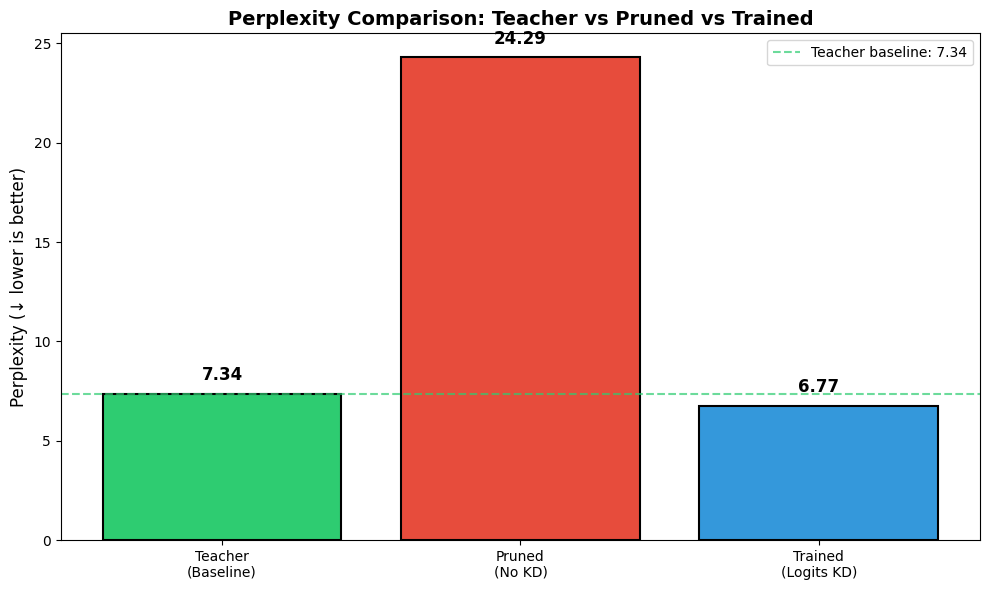


✓ Recovery: 103.4% of degradation recovered


In [22]:
# Perplexity Bar Chart
models = ['Teacher\n(Baseline)', 'Pruned\n(No KD)', 'Trained\n(Logits KD)']
ppls = [teacher_ppl, student_ppl, trained_ppl]
colors = ['#2ecc71', '#e74c3c', '#3498db']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models, ppls, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Perplexity (↓ lower is better)', fontsize=12)
ax.set_title('Perplexity Comparison: Teacher vs Pruned vs Trained', fontsize=14, fontweight='bold')
for bar, ppl in zip(bars, ppls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{ppl:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.axhline(y=teacher_ppl, color='#2ecc71', linestyle='--', alpha=0.7, label=f'Teacher baseline: {teacher_ppl:.2f}')
ax.legend()
plt.tight_layout()
plt.savefig('ppl_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Recovery: {recovery_pct:.1f}% of degradation recovered")

In [23]:

print("Keys en benchmark_results:", benchmark_results.keys())
print("\nEstructura de 'teacher':")
if RUN_FULL_BENCHMARKS:
  print(type(benchmark_results['teacher']))
  if isinstance(benchmark_results['teacher'], dict):
      print("Keys:", benchmark_results['teacher'].keys())
      # Ver un ejemplo de tarea
      for key in list(benchmark_results['teacher'].keys())[:2]:
          print(f"\n{key}: {benchmark_results['teacher'][key]}")

Keys en benchmark_results: dict_keys(['teacher', 'student_pruned', 'labels_only_trained'])

Estructura de 'teacher':
<class 'dict'>
Keys: dict_keys(['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa'])

arc_easy: {'accuracy': '0.7062', 'acc_norm': '0.6747'}

winogrande: {'accuracy': '0.5943'}


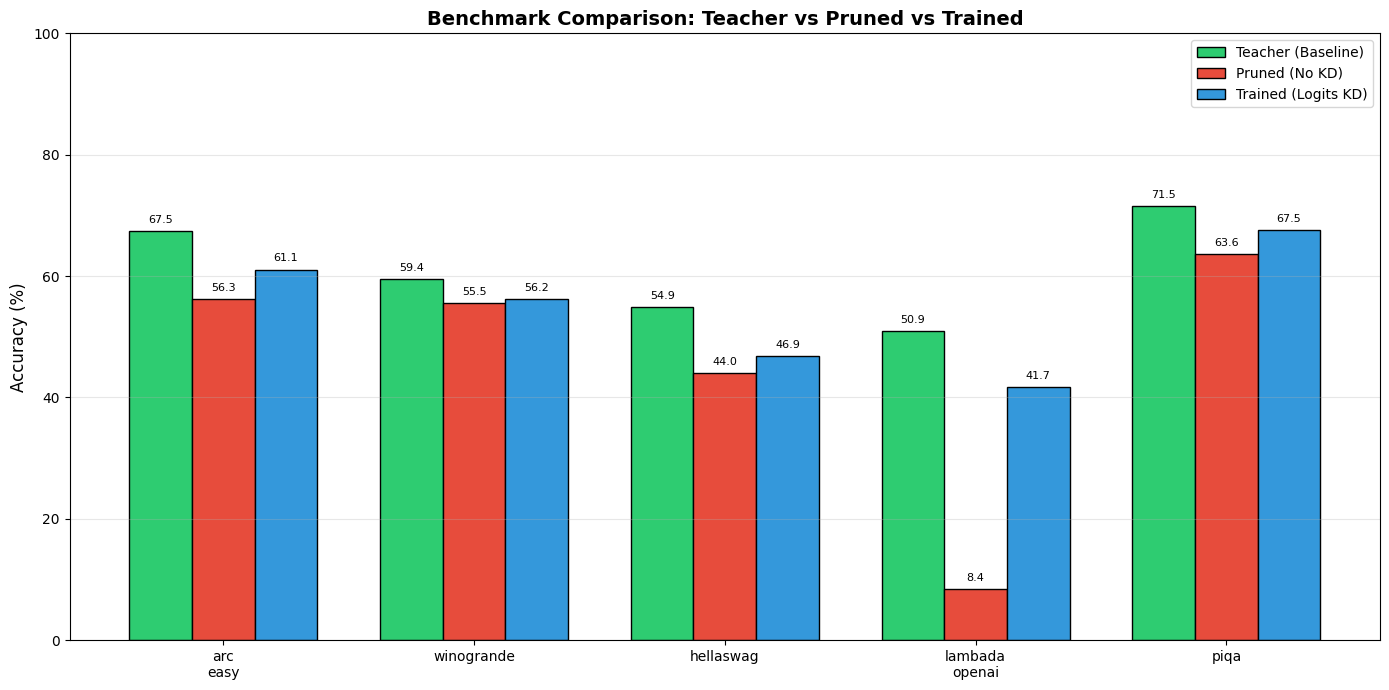


Benchmark Average: Teacher=60.8%, Pruned=45.5%, Trained=54.7%
Benchmark Recovery: 59.6%

Detalle por tarea:
  arc_easy            : Teacher=67.5%  Pruned=56.3%  Trained=61.1%
  winogrande          : Teacher=59.4%  Pruned=55.5%  Trained=56.2%
  hellaswag           : Teacher=54.9%  Pruned=44.0%  Trained=46.9%
  lambada_openai      : Teacher=50.9%  Pruned=8.4%  Trained=41.7%
  piqa                : Teacher=71.5%  Pruned=63.6%  Trained=67.5%


In [24]:
# Benchmark Bar Chart
if RUN_FULL_BENCHMARKS and benchmark_results:
    tasks = BENCHMARK_TASKS
    x = np.arange(len(tasks))
    width = 0.25

    # Función helper para extraer scores con fallback
    def get_score(model_results, task):
        task_data = model_results.get(task, {})
        # Prioridad: acc_norm, luego accuracy
        score_str = task_data.get('acc_norm', task_data.get('accuracy', '0'))
        return float(score_str) * 100

    teacher_scores = [get_score(benchmark_results['teacher'], t) for t in tasks]
    pruned_scores = [get_score(benchmark_results['student_pruned'], t) for t in tasks]
    trained_scores = [get_score(benchmark_results['labels_only_trained'], t) for t in tasks]

    fig, ax = plt.subplots(figsize=(14, 7))
    bars1 = ax.bar(x - width, teacher_scores, width, label='Teacher (Baseline)', color='#2ecc71', edgecolor='black')
    bars2 = ax.bar(x, pruned_scores, width, label='Pruned (No KD)', color='#e74c3c', edgecolor='black')
    bars3 = ax.bar(x + width, trained_scores, width, label='Trained (Logits KD)', color='#3498db', edgecolor='black')

    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Benchmark Comparison: Teacher vs Pruned vs Trained', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([t.replace('_', '\n') for t in tasks], fontsize=10)
    ax.legend(loc='upper right')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)

    def add_labels(bars):
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.1f}', ha='center', va='bottom', fontsize=8)

    add_labels(bars1)
    add_labels(bars2)
    add_labels(bars3)

    plt.tight_layout()
    plt.savefig('benchmark_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print average recovery
    avg_teacher = np.mean(teacher_scores)
    avg_pruned = np.mean(pruned_scores)
    avg_trained = np.mean(trained_scores)
    bench_degradation = avg_teacher - avg_pruned
    bench_recovered = avg_trained - avg_pruned
    bench_recovery_pct = (bench_recovered / bench_degradation) * 100 if bench_degradation > 0 else 0

    print(f"\nBenchmark Average: Teacher={avg_teacher:.1f}%, Pruned={avg_pruned:.1f}%, Trained={avg_trained:.1f}%")
    print(f"Benchmark Recovery: {bench_recovery_pct:.1f}%")

    # Detalle por tarea
    print("\nDetalle por tarea:")
    for i, task in enumerate(tasks):
        print(f"  {task:20s}: Teacher={teacher_scores[i]:.1f}%  Pruned={pruned_scores[i]:.1f}%  Trained={trained_scores[i]:.1f}%")

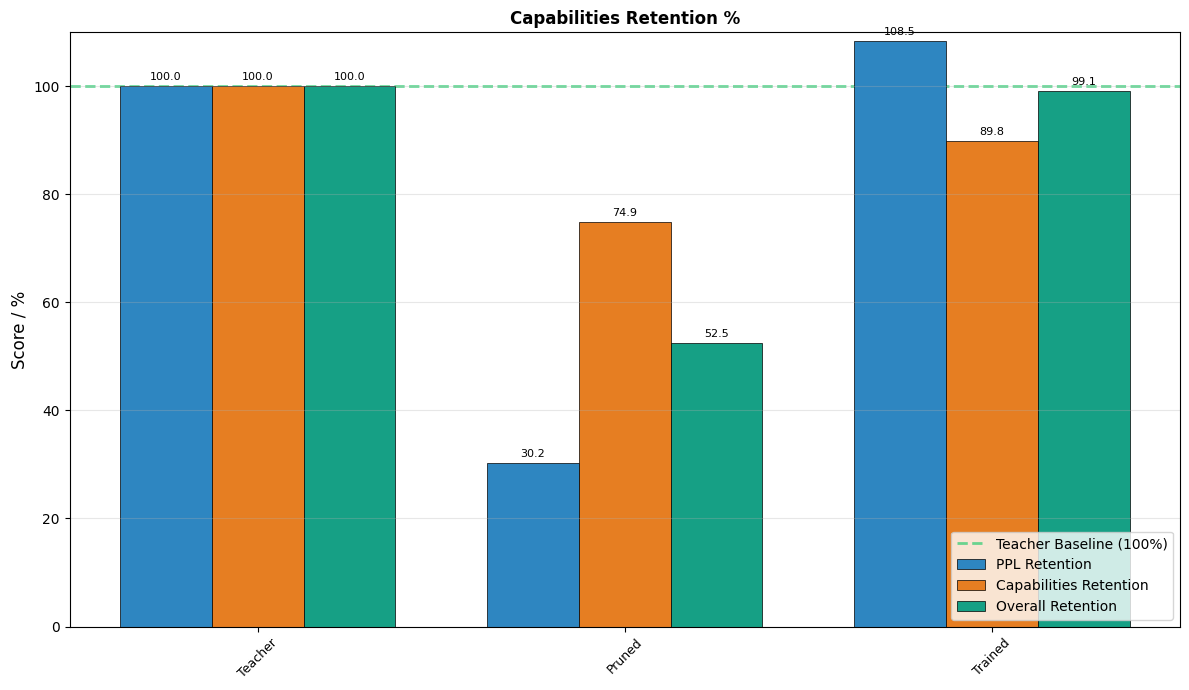


RETENTION SUMMARY (vs Teacher Baseline)
Model                 PPL Ret %       Cap Ret %       Overall %
----------------------------------------------------------------------
Teacher                  100.0%          100.0%          100.0%
Pruned                    30.2%           74.9%           52.5%
Trained                  108.5%           89.8%           99.1%

KEY INSIGHTS:
  • PPL Retention: 108.5% (Teacher PPL / Student PPL)
  • Capabilities Retention: 89.8% (Avg benchmark score / Teacher score)
  • Overall Retention: 99.1% (Average of both metrics)

  • KD Training recovered 46.6 percentage points


In [25]:
# Capabilities Retention
if RUN_FULL_BENCHMARKS and benchmark_results:


    # A. Capabilities Retention (
    teacher_avg_acc = np.mean(teacher_scores)
    pruned_avg_acc = np.mean(pruned_scores)
    trained_avg_acc = np.mean(trained_scores)

    cap_retention = {
        'teacher': 100.0,
        'pruned': (pruned_avg_acc / teacher_avg_acc * 100) if teacher_avg_acc > 0 else 0,
        'trained': (trained_avg_acc / teacher_avg_acc * 100) if teacher_avg_acc > 0 else 0
    }

    # B. PPL Retention
    # Fórmula: (Teacher PPL / Student PPL) * 100
    ppl_retention = {
        'teacher': 100.0,
        'pruned': (teacher_ppl / student_ppl * 100) if student_ppl > 0 else 0,
        'trained': (teacher_ppl / trained_ppl * 100) if trained_ppl > 0 else 0
    }

    # C. Overall Retention Score
    overall_retention = {
        'teacher': 100.0,
        'pruned': (ppl_retention['pruned'] + cap_retention['pruned']) / 2,
        'trained': (ppl_retention['trained'] + cap_retention['trained']) / 2
    }


    model_names = ['Teacher', 'Pruned', 'Trained']
    model_keys = ['teacher', 'pruned', 'trained']

    colors_models = ['#2ecc71', '#e74c3c', '#5dade2']  # Green, Red, Blue

    retention_metrics = {
        'PPL Retention %': [ppl_retention[k] for k in model_keys],
        'Capabilities Retention %': [cap_retention[k] for k in model_keys],
        'Overall Retention Score %': [overall_retention[k] for k in model_keys]
    }


    fig, ax = plt.subplots(figsize=(12, 7))

    x = np.arange(len(model_names))
    width = 0.25

    bars1 = ax.bar(x - width, retention_metrics['PPL Retention %'], width,
                   label='PPL Retention', color='#2e86c1', edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x, retention_metrics['Capabilities Retention %'], width,
                   label='Capabilities Retention', color='#e67e22', edgecolor='black', linewidth=0.5)
    bars3 = ax.bar(x + width, retention_metrics['Overall Retention Score %'], width,
                   label='Overall Retention', color='#16a085', edgecolor='black', linewidth=0.5)

    ax.axhline(y=100, color='#2ecc71', linestyle='--', linewidth=2, alpha=0.7,
               label='Teacher Baseline (100%)', zorder=0)

    ax.set_ylabel('Score / %', fontsize=12)
    ax.set_title('Capabilities Retention %', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.legend(loc='lower right', fontsize=10)
    ax.set_ylim(0, 110)
    ax.grid(True, alpha=0.3, axis='y')

    def add_bar_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=8)

    add_bar_labels(bars1)
    add_bar_labels(bars2)
    add_bar_labels(bars3)

    plt.tight_layout()
    plt.savefig('capabilities_retention_summary.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n{'='*70}")
    print(f"RETENTION SUMMARY (vs Teacher Baseline)")
    print(f"{'='*70}")
    print(f"{'Model':<15} {'PPL Ret %':>15} {'Cap Ret %':>15} {'Overall %':>15}")
    print(f"{'-'*70}")
    for i, key in enumerate(model_keys):
        print(f"{model_names[i]:<15} {ppl_retention[key]:>14.1f}% {cap_retention[key]:>14.1f}% {overall_retention[key]:>14.1f}%")
    print(f"{'='*70}")

    print(f"\nKEY INSIGHTS:")
    print(f"  • PPL Retention: {ppl_retention['trained']:.1f}% (Teacher PPL / Student PPL)")
    print(f"  • Capabilities Retention: {cap_retention['trained']:.1f}% (Avg benchmark score / Teacher score)")
    print(f"  • Overall Retention: {overall_retention['trained']:.1f}% (Average of both metrics)")
    print(f"\n  • KD Training recovered {overall_retention['trained'] - overall_retention['pruned']:.1f} percentage points")

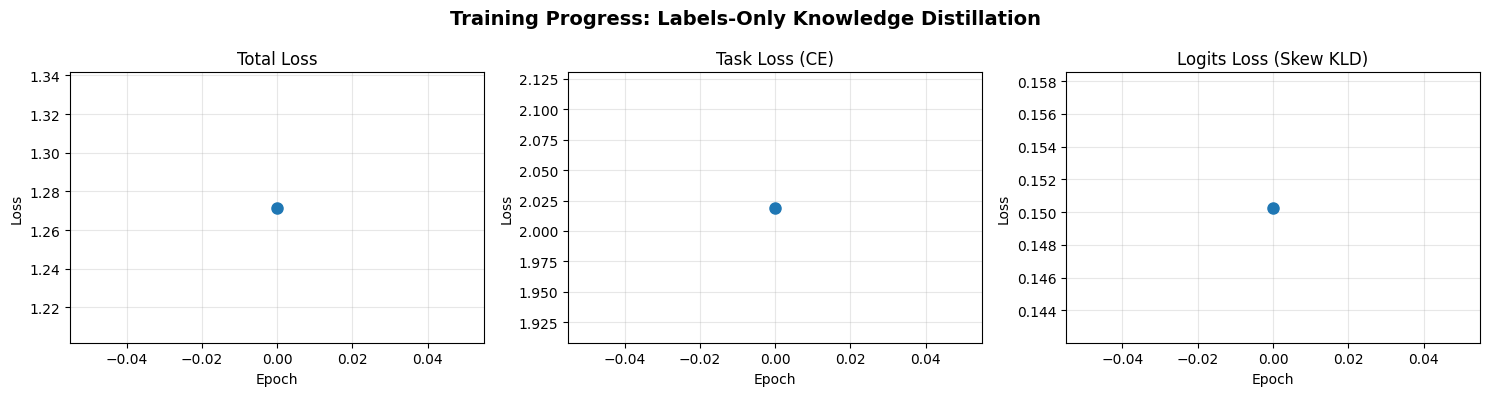

In [26]:
# Training Loss Curves - Extract only relevant losses (trajectory & derivative are 0)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
loss_keys = [
    ('total', 'Total Loss'),
    ('task', 'Task Loss (CE)'),
    ('logits', 'Logits Loss (Skew KLD)')
]
for idx, (key, title) in enumerate(loss_keys):
    axes[idx].plot(history[key], marker='o', linewidth=2, markersize=8)
    axes[idx].set_title(title, fontsize=12)
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('Loss')
    axes[idx].grid(True, alpha=0.3)
plt.suptitle('Training Progress: Labels-Only Knowledge Distillation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6.5: Save Experiment Results

In [27]:
# Section 6.5: Save Experiment Results
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer): return int(obj)
        if isinstance(obj, np.floating): return float(obj)
        if isinstance(obj, np.ndarray): return obj.tolist()
        return super().default(obj)

def calculate_retention_metrics(model_ppl, model_bench_scores, teacher_ppl, teacher_bench_scores):
    """
    Calcula las métricas de retención vs teacher
    """
    # A. PPL Retention
    ppl_retention = (teacher_ppl / model_ppl * 100) if model_ppl > 0 else 0

    # B. Capabilities Retention
    teacher_avg = np.mean(teacher_bench_scores)
    model_avg = np.mean(model_bench_scores)
    cap_retention = (model_avg / teacher_avg * 100) if teacher_avg > 0 else 0

    # C. Overall Retention
    individual_retentions = []
    for i in range(len(teacher_bench_scores)):
        if teacher_bench_scores[i] > 0:
            ret = (model_bench_scores[i] / teacher_bench_scores[i] * 100)
            individual_retentions.append(ret)

    individual_retentions.append(ppl_retention)

    overall_retention = np.mean(individual_retentions)

    return {
        "retention_%": round(ppl_retention, 2),
        "cap_retention_%": round(cap_retention, 2),
        "overall_retention_%": round(overall_retention, 2)
    }

teacher_retention = calculate_retention_metrics(
    teacher_ppl, teacher_scores, teacher_ppl, teacher_scores
)

pruned_retention = calculate_retention_metrics(
    student_ppl, pruned_scores, teacher_ppl, teacher_scores
)

trained_retention = calculate_retention_metrics(
    trained_ppl, trained_scores, teacher_ppl, teacher_scores
)

results_data = {
    "metadata": {
        "experiment_name": "Labels-Only KD with Skew KLD",
        "timestamp": datetime.now().isoformat(),
        "dataset": "Cosmopedia (40k samples)",
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE
    },
    "models": {
        "teacher": MODEL_NAME,
        "student": f"Gemma-270m-Pruned ({n_student_layers} layers)"
    },
    "training_config": {
        "alpha": 0.5,
        "beta": 0.5,
        "gamma": 0.0,
        "delta": 0.0,
        "skew_alpha": 0.0,
        "temperature": 2.0,
        "learning_rate": LEARNING_RATE,
        "accumulation_steps": 4
    },
    "results": {
        "teacher": {
            "perplexity": round(teacher_ppl, 2),
            "loss": round(teacher_loss, 4),
            "retention_%": teacher_retention["retention_%"],
            "cap_retention_%": teacher_retention["cap_retention_%"],
            "overall_retention_%": teacher_retention["overall_retention_%"]
        },
        "student_pruned": {
            "perplexity": round(student_ppl, 2),
            "loss": round(student_loss, 4),
            "retention_%": pruned_retention["retention_%"],
            "cap_retention_%": pruned_retention["cap_retention_%"],
            "overall_retention_%": pruned_retention["overall_retention_%"]
        },
        "labels_only_trained": {
            "perplexity": round(trained_ppl, 2),
            "loss": round(trained_loss, 4),
            "recovery_pct": round(recovery_pct, 1),
            "retention_%": trained_retention["retention_%"],
            "cap_retention_%": trained_retention["cap_retention_%"],
            "overall_retention_%": trained_retention["overall_retention_%"]
        }
    }
}

if RUN_FULL_BENCHMARKS and benchmark_results:
    for model_key in ['teacher', 'student_pruned', 'labels_only_trained']:
        if model_key in benchmark_results:
            results_data['results'][model_key]['benchmarks'] = benchmark_results[model_key]

json_path = "/content/drive/MyDrive/ch06nb01/CH06_NB02_Logits_KLD_results.json"
os.makedirs(os.path.dirname(json_path), exist_ok=True)
with open(json_path, 'w') as f:
    json.dump(results_data, f, indent=2, cls=NumpyEncoder)
print(f"✓ Results saved to: {json_path}")

with open("CH06_NB02_Logits_KLD_results.json", 'w') as f:
    json.dump(results_data, f, indent=2, cls=NumpyEncoder)
print("✓ Local backup saved")

# Mostrar resumen de retención
print(f"\n{'='*70}")
print(f"RETENTION METRICS SAVED TO JSON")
print(f"{'='*70}")
print(f"{'Model':<20} {'PPL Ret':>12} {'Cap Ret':>12} {'Overall':>12}")
print(f"{'-'*70}")
print(f"{'Teacher':<20} {teacher_retention['retention_%']:>11.2f}% {teacher_retention['cap_retention_%']:>11.2f}% {teacher_retention['overall_retention_%']:>11.2f}%")
print(f"{'Pruned':<20} {pruned_retention['retention_%']:>11.2f}% {pruned_retention['cap_retention_%']:>11.2f}% {pruned_retention['overall_retention_%']:>11.2f}%")
print(f"{'Trained':<20} {trained_retention['retention_%']:>11.2f}% {trained_retention['cap_retention_%']:>11.2f}% {trained_retention['overall_retention_%']:>11.2f}%")
print(f"{'='*70}")

✓ Results saved to: /content/drive/MyDrive/ch06nb01/CH06_NB02_Logits_KLD_results.json
✓ Local backup saved

RETENTION METRICS SAVED TO JSON
Model                     PPL Ret      Cap Ret      Overall
----------------------------------------------------------------------
Teacher                   100.00%      100.00%      100.00%
Pruned                     30.23%       74.86%       65.43%
Trained                   108.45%       89.85%       92.53%


In [28]:
import os

# Define the path in your Drive (adjust as needed)
save_directory = "/content/drive/MyDrive/ch06nb01/student_model_saved"
os.makedirs(save_directory, exist_ok=True)

# Save the model and the tokenizer
student_trained.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)

print(f"✅ Model safely saved to: {save_directory}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model safely saved to: /content/drive/MyDrive/ch06nb01/student_model_saved


## Section 7: Save Model to Hugging Face

In [29]:
def generate_model_card(
    results_data,
    model_name,
    hf_username,
    teacher_scores,
    pruned_scores,
    trained_scores,
    benchmark_tasks,
    layers_removed_indices,
    output_path="README.md"
):
    """
    Generate a comprehensive Hugging Face Model Card for the distilled model.

    Args:
        results_data: Dict with all experiment results (from Section 6.5)
        model_name: Name for the model (e.g., "gemma-3-270m-14L-distilled")
        hf_username: Your Hugging Face username
        teacher_scores: List of teacher benchmark scores
        pruned_scores: List of pruned benchmark scores
        trained_scores: List of trained benchmark scores
        benchmark_tasks: List of benchmark task names
        layers_removed_indices: List of layer indices that were removed
        output_path: Where to save the README.md file
    """

    # =========================================================================
    # EXTRACT METRICS FROM results_data
    # =========================================================================

    # Model info
    teacher_params = results_data['results']['teacher'].get('parameters', 'N/A')
    student_params = results_data['results']['labels_only_trained'].get('parameters', 'N/A')

    # If parameters not in results, calculate from model
    if teacher_params == 'N/A':
        teacher_params = f"{teacher_model.num_parameters():,}"
        student_params = f"{student_trained.num_parameters():,}"

    param_reduction = ((teacher_model.num_parameters() - student_trained.num_parameters())
                       / teacher_model.num_parameters() * 100)

    # PPL metrics
    teacher_ppl = results_data['results']['teacher']['perplexity']
    pruned_ppl = results_data['results']['student_pruned']['perplexity']
    student_ppl = results_data['results']['labels_only_trained']['perplexity']
    student_loss = results_data['results']['labels_only_trained']['loss']

    # Retention metrics
    ppl_retention = results_data['results']['labels_only_trained']['retention_%']
    cap_retention = results_data['results']['labels_only_trained']['cap_retention_%']
    overall_retention = results_data['results']['labels_only_trained']['overall_retention_%']

    # Training config
    config = results_data['training_config']
    alpha = config['alpha']
    beta = config['beta']
    skew_alpha = config['skew_alpha']
    temperature = config['temperature']
    learning_rate = config['learning_rate']
    accumulation_steps = config['accumulation_steps']

    # Training metadata
    metadata = results_data['metadata']
    epochs = metadata['epochs']
    batch_size = metadata['batch_size']
    effective_batch_size = batch_size * accumulation_steps
    num_samples = RECOVERY_SAMPLES

    # Training time
    total_time = history['total_time_seconds']
    total_minutes = total_time / 60
    avg_epoch_time = np.mean(history['epoch_times_seconds'])

    # GPU info
    gpu_type = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

    # =========================================================================
    # CALCULATE RECOVERY METRICS PER BENCHMARK
    # =========================================================================

    def calculate_recovery(teacher, pruned, trained):
        """Calculate recovery percentage: how much of the gap was closed"""
        degradation = teacher - pruned
        if degradation <= 0:
            return 0.0  # No degradation or improved after pruning (rare)
        recovered = trained - pruned
        return (recovered / degradation * 100)

    recovery_scores = []
    for i in range(len(benchmark_tasks)):
        recovery = calculate_recovery(teacher_scores[i], pruned_scores[i], trained_scores[i])
        recovery_scores.append(recovery)

    # Average recovery
    teacher_avg = np.mean(teacher_scores)
    pruned_avg = np.mean(pruned_scores)
    trained_avg = np.mean(trained_scores)
    recovery_avg = calculate_recovery(teacher_avg, pruned_avg, trained_avg)

    # =========================================================================
    # BUILD THE MODEL CARD
    # =========================================================================

    model_card = f"""---
language:
- en
tags:
- optipfair
- rearchitecting-llms
- knowledge-distillation
- depth-pruning
- model-optimization
- small-language-model
- gemma
- educational
license: apache-2.0
base_model: google/gemma-3-270m
metrics:
- perplexity
- accuracy
datasets:
- HuggingFaceTB/cosmopedia
---

# {model_name}

## Model Description

This model is a surgically optimized and distilled version of **Qwen3.5-0.5B-Base-Rearchitected**,
created with the techniques covered in **Chapter 6** in the book **"Rearchitecting LLMs"**.

* **Book:** [Rearchitecting LLMs](https://hubs.la/Q040tvtp0)
* **Framework:** [OptiPFair](https://github.com/peremartra/optipfair)
* **Technique:** Depth Pruning + Knowledge Distillation (Labels-Only with Skew KL Divergence)
* **Chapter:** Chapter 6 - Knowledge Recovery

---

## Performance & Retention Metrics

The goal of this optimization was to maximize parameter efficiency while maintaining the highest possible retention of the Teacher's capabilities.

### Retention Summary (vs Teacher Baseline)

| Metric | Value | Description |
|:---|:---|:---|
| **PPL Retention** | {ppl_retention:.2f}% | Linguistic quality preserved (Teacher PPL / Student PPL × 100) |
| **Capabilities Retention** | {cap_retention:.2f}% | Reasoning power retained across benchmarks (Avg Student / Avg Teacher × 100) |
| **Overall Retention** | {overall_retention:.2f}% | Combined health score (average of PPL + Capabilities retention) |

### Capability Benchmarks (LM Evaluation Harness)

**Recovery** = How much of the pruning degradation was recovered through distillation.

| Benchmark | Teacher | Pruned (No KD) | Student (After KD) | Recovery |
|:---|:---:|:---:|:---:|:---:|
"""

    # Add benchmark rows
    for i, task in enumerate(benchmark_tasks):
        task_name = task.replace('_', ' ').title()
        model_card += f"| **{task_name}** | {teacher_scores[i]:.1f}% | {pruned_scores[i]:.1f}% | {trained_scores[i]:.1f}% | {recovery_scores[i]:.1f}% |\n"

    model_card += f"| **Average** | {teacher_avg:.1f}% | {pruned_avg:.1f}% | {trained_avg:.1f}% | {recovery_avg:.1f}% |\n"

    model_card += f"""
### Linguistic Quality

* **Final Perplexity (PPL):** {student_ppl:.2f}
* **Teacher Baseline PPL:** {teacher_ppl:.2f}
* **Pruned (No KD) PPL:** {pruned_ppl:.2f}

---

## Architecture Details

* **Teacher Model:** `Qwen3.5-0.5B-Base-Rearchitected` ({teacher_params} parameters)
* **Student Model:** Pruned to ({student_params} parameters)
* **Layers Removed:** {len(layers_removed_indices)} layers (indices: {layers_removed_indices})
* **Parameter Reduction:** {param_reduction:.2f}%

---

## Training Procedure

### Dataset
* **Source:** [Cosmopedia-v2](https://huggingface.co/datasets/HuggingFaceTB/cosmopedia)
* **Samples:** {num_samples:,} (balanced across 4 subsets: stories, wikihow, openstax, web_samples)
* **Train/Val Split:** 80% / 20%

### Hyperparameters
* **Epochs:** {epochs}
* **Batch Size:** {batch_size} (effective: {effective_batch_size} with gradient accumulation)
* **Learning Rate:** {learning_rate}
* **Loss Function:** `α·CrossEntropy + β·Skew-KLD`
  * Task Loss Weight (α): {alpha}
  * Logits Loss Weight (β): {beta}
  * Skew Interpolation Factor: {skew_alpha}
  * Temperature: {temperature}
* **Optimizer:** AdamW
* **Gradient Clipping:** 1.0

### Hardware & Training Time
* **GPU:** {gpu_type}
* **Training Time:** {total_time:.1f}s ({total_minutes:.2f} minutes)
* **Avg Time per Epoch:** {avg_epoch_time:.1f}s

---

## How to Use
```python
from transformers import AutoModelForCausalLM, AutoTokenizer

# Load model and tokenizer
model_id = "{hf_username}/{model_name}"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id)

# Generate text
prompt = "Paris is the capital of"
inputs = tokenizer(prompt, return_tensors="pt")
outputs = model.generate(
    **inputs,
    max_new_tokens=50,
    do_sample=False,
    num_beams=3
)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))
```

---

## Limitations & Intended Use

### Intended Use
This is an **educational model** created as part of the **Hands-on Lab in Chapter 6** of "Rearchitecting LLMs". It demonstrates:
- Surgical depth pruning using data-driven layer importance analysis
- Knowledge recovery through labels-only distillation with Skew KL Divergence
- The complete optimization pipeline: Prune → Distill → Evaluate

**Not intended for production use.** This model serves as a learning artifact and baseline for readers to improve upon.

### Limitations
- **Training Data:** General-purpose Cosmopedia corpus (not domain-specialized)
- **Knowledge Coverage:** Reduced compared to full-scale models due to structural pruning
- **Capabilities:** Best suited for simple completion tasks; complex reasoning may be degraded
- **Language:** English only

---

## Citation

If you use this model or the techniques described in your research or projects, please cite:

### Book
```bibtex
@book{{martra2026rearchitecting,
  author    = {{Pere Martra}},
  title     = {{Rearchitecting LLMs: Structural techniques for efficient models}},
  publisher = {{Manning Publications}},
  year      = {{2026}},
  url       = {{https://hubs.la/Q040tvtp0}}
}}
```

### Framework
```bibtex
@software{{optipfair2024,
  author = {{Pere Martra}},
  title  = {{OptiPFair: Structural Pruning and Bias Analysis for LLMs}},
  year   = {{2024}},
  url    = {{https://github.com/peremartra/optipfair}}
}}
```

---

## Acknowledgments

This model was created following the methodologies taught in **"Rearchitecting LLMs"** (Manning Publications, 2026). Special thanks to the Manning editorial team and the open-source community behind Hugging Face Transformers and PyTorch.

**Challenge for readers:** Can you improve the retention metrics beyond {overall_retention:.1f}%? Try adjusting:
- Layer selection strategy (use cosine similarity analysis)
- Distillation dataset (domain-specific data)
- Loss function weights (α, β, temperature)
- Training epochs and learning rate

Share your results in the [book's discussion forum](https://hubs.la/Q040tvtp0)!
"""

    # =========================================================================
    # SAVE TO FILE
    # =========================================================================

    with open(output_path, 'w', encoding='utf-8') as f:
        f.write(model_card)

    print(f"✓ Model card generated: {output_path}")
    print(f"\nKey Metrics:")
    print(f"  • Overall Retention: {overall_retention:.1f}%")
    print(f"  • Benchmark Recovery: {recovery_avg:.1f}%")
    print(f"  • Parameter Reduction: {param_reduction:.1f}%")

    return model_card

In [30]:
# DEBUG: Verificar que las variables existen
print("Verificando variables necesarias:")
print(f"  teacher_ppl: {teacher_ppl}")
print(f"  student_ppl: {student_ppl}")
print(f"  trained_ppl: {trained_ppl}")
print(f"  teacher_loss: {teacher_loss}")
print(f"  student_loss: {student_loss}")
print(f"  trained_loss: {trained_loss}")

Verificando variables necesarias:
  teacher_ppl: 7.343361108817394
  student_ppl: 24.287769302647828
  trained_ppl: 6.771073121511184
  teacher_loss: 1.9937966545471677
  student_loss: 3.1899729027593406
  trained_loss: 1.9126595856640989


In [31]:
print("Verificando losses (antes de calcular perplexity):")
print(f"  teacher_loss: {teacher_loss}")
print(f"  student_loss: {student_loss}")
print(f"  trained_loss: {trained_loss}")

Verificando losses (antes de calcular perplexity):
  teacher_loss: 1.9937966545471677
  student_loss: 3.1899729027593406
  trained_loss: 1.9126595856640989


In [32]:
# =========================================================================
# Section 7: Generate Model Card for Hugging Face
# =========================================================================

print("Generating Model Card...")

model_card = generate_model_card(
    results_data=results_data,
    model_name=HF_MODEL_NAME,  # "gem-3-small" from your constants
    hf_username="oopere",  # <-- El lector debe poner el suyo
    teacher_scores=teacher_scores,
    pruned_scores=pruned_scores,
    trained_scores=trained_scores,
    benchmark_tasks=BENCHMARK_TASKS,
    layers_removed_indices=LAYERS_TO_REMOVE,
    output_path="README.md"
)

print("\n" + "="*70)
print("MODEL CARD READY FOR UPLOAD")
print("="*70)
print(f"\nNext steps:")
print(f"1. Review the generated README.md file")
print(f"2. Update 'YOUR_HF_USERNAME' with your actual username")
print(f"3. Upload model with: student_trained.push_to_hub('{HF_MODEL_NAME}')")
print(f"4. Upload README.md to your model repository")
print("="*70)


Generating Model Card...
✓ Model card generated: README.md

Key Metrics:
  • Overall Retention: 92.5%
  • Benchmark Recovery: 59.6%
  • Parameter Reduction: 11.5%

MODEL CARD READY FOR UPLOAD

Next steps:
1. Review the generated README.md file
2. Update 'YOUR_HF_USERNAME' with your actual username
3. Upload model with: student_trained.push_to_hub('Qwen3.5-0.65B-Base-Rearchitected')
4. Upload README.md to your model repository


In [33]:
#print(f"Saving model to HuggingFace as '{HF_MODEL_NAME}'...")
#student_trained.push_to_hub(HF_MODEL_NAME, commit_message="Depth-pruned Gemma-3-270m with Labels-Only KD")
#tokenizer.push_to_hub(HF_MODEL_NAME, commit_message="Tokenizer for gem-3-small")
#print(f"✓ Model saved: https://huggingface.co/{HF_MODEL_NAME}")

In [34]:
# =========================================================================
# Section 8: Upload Model to Hugging Face (with Model Card)
# =========================================================================

from huggingface_hub import HfApi
import os

api = HfApi()
HF_USERNAME = api.whoami()['name']
print(f"Detected HF username: {HF_USERNAME}")


MODEL_SAVE_DIR = f"./{HF_MODEL_NAME}"

print(f"Preparing model for upload: {HF_USERNAME}/{HF_MODEL_NAME}")
print("="*70)


print("1. Saving model and tokenizer...")
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)


student_trained.save_pretrained(MODEL_SAVE_DIR)
tokenizer.save_pretrained(MODEL_SAVE_DIR)
print(f"   ✓ Model saved to {MODEL_SAVE_DIR}")


print("2. Generating model card...")
readme_path = os.path.join(MODEL_SAVE_DIR, "README.md")

model_card = generate_model_card(
    results_data=results_data,
    model_name=HF_MODEL_NAME,
    hf_username=HF_USERNAME,
    teacher_scores=teacher_scores,
    pruned_scores=pruned_scores,
    trained_scores=trained_scores,
    benchmark_tasks=BENCHMARK_TASKS,
    layers_removed_indices=LAYERS_TO_REMOVE,
    output_path=readme_path
)
print(f"   ✓ Model card saved to {readme_path}")


print("3. Uploading to Hugging Face Hub...")
print(f"   Repository: https://huggingface.co/{HF_USERNAME}/{HF_MODEL_NAME}")

try:

    student_trained.push_to_hub(
        repo_id=f"{HF_USERNAME}/{HF_MODEL_NAME}",
        commit_message="Initial upload: Depth-pruned + KD model from Chapter 6"
    )


    tokenizer.push_to_hub(
        repo_id=f"{HF_USERNAME}/{HF_MODEL_NAME}",
    )


    api = HfApi()
    api.upload_file(
        path_or_fileobj=readme_path,
        path_in_repo="README.md",
        repo_id=f"{HF_USERNAME}/{HF_MODEL_NAME}",
        commit_message="Add model card"
    )

    print("\n" + "="*70)
    print("✅ UPLOAD SUCCESSFUL!")
    print("="*70)
    print(f"\n🎉 Your model is live at:")
    print(f"   https://huggingface.co/{HF_USERNAME}/{HF_MODEL_NAME}")
    print("\n📊 Model Card Preview:")
    print(f"   - Overall Retention: {results_data['results']['labels_only_trained']['overall_retention_%']:.1f}%")
    print("\n🏆 Challenge: Can other readers beat your retention score?")
    print("="*70)

except Exception as e:
    print("\n❌ Upload failed:")
    print(f"   Error: {str(e)}")
    print("\n💡 Troubleshooting:")
    print("   1. Make sure you've set HF_USERNAME correctly")
    print("   2. Authenticate with: huggingface-cli login")
    print("   3. Or provide HF_TOKEN manually")
    print(f"   4. Check repository permissions for: {HF_USERNAME}/{HF_MODEL_NAME}")

Detected HF username: oopere
Preparing model for upload: oopere/Qwen3.5-0.65B-Base-Rearchitected
1. Saving model and tokenizer...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   ✓ Model saved to ./Qwen3.5-0.65B-Base-Rearchitected
2. Generating model card...
✓ Model card generated: ./Qwen3.5-0.65B-Base-Rearchitected/README.md

Key Metrics:
  • Overall Retention: 92.5%
  • Benchmark Recovery: 59.6%
  • Parameter Reduction: 11.5%
   ✓ Model card saved to ./Qwen3.5-0.65B-Base-Rearchitected/README.md
3. Uploading to Hugging Face Hub...
   Repository: https://huggingface.co/oopere/Qwen3.5-0.65B-Base-Rearchitected


README.md: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  ...w3yqg1h/model.safetensors:   0%|          |  609kB / 1.33GB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpz8dmei4z/tokenizer.json: 100%|##########| 20.0MB / 20.0MB            


✅ UPLOAD SUCCESSFUL!

🎉 Your model is live at:
   https://huggingface.co/oopere/Qwen3.5-0.65B-Base-Rearchitected

📊 Model Card Preview:
   - Overall Retention: 92.5%

🏆 Challenge: Can other readers beat your retention score?
